# 01 — Exploratory Data Analysis
**TrustGraph Credit Risk Project**

This notebook profiles `application_train.csv` and produces charts saved to `data/processed/eda_charts/`.

> **Before running:** place `application_train.csv` inside `data/raw/`.

In [1]:
import os
import sys
import time
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT       = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
DATA_RAW   = ROOT / 'data' / 'raw'
DATA_PROC  = ROOT / 'data' / 'processed'
CHARTS_DIR = DATA_PROC / 'eda_charts'
DATA_FILE  = DATA_RAW / 'application_train.csv'

CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Wait for data ──────────────────────────────────────────────────────────
if not DATA_FILE.exists():
    print("=" * 60)
    print("  DATA FILE NOT FOUND")
    print("=" * 60)
    print(f"\n  Expected: {DATA_FILE}")
    print("\n  Please copy application_train.csv into data/raw/ and")
    print("  re-run this cell. All subsequent cells are ready to go.")
    print("\n  Waiting... (re-run cell once file is in place)")
    print("=" * 60)
    raise FileNotFoundError(
        f"application_train.csv not found at {DATA_FILE}. "
        "Copy the file there and re-run this cell."
    )
else:
    print(f"Data file found: {DATA_FILE}")
    print("All cells are ready to run.")

Data file found: C:\Users\krish\Downloads\TrustGraph\data\raw\application_train.csv
All cells are ready to run.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(DATA_FILE)
print(f"Shape: {df.shape}")
df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Schema & dtypes

In [3]:
summary = pd.DataFrame({
    'dtype':   df.dtypes,
    'n_null':  df.isnull().sum(),
    'pct_null': (df.isnull().mean() * 100).round(2),
    'n_unique': df.nunique(),
})
summary.sort_values('pct_null', ascending=False).head(30)

,dtype,n_null,pct_null,n_unique
COMMONAREA_AVG,float64,214865,69.87,3181
COMMONAREA_MODE,float64,214865,69.87,3128
COMMONAREA_MEDI,float64,214865,69.87,3202
NONLIVINGAPARTMENTS_MEDI,float64,213514,69.43,214
NONLIVINGAPARTMENTS_MODE,float64,213514,69.43,167
NONLIVINGAPARTMENTS_AVG,float64,213514,69.43,386
FONDKAPREMONT_MODE,str,210295,68.39,4
LIVINGAPARTMENTS_AVG,float64,210199,68.35,1868
LIVINGAPARTMENTS_MEDI,float64,210199,68.35,1097
LIVINGAPARTMENTS_MODE,float64,210199,68.35,736


## 2. Target distribution

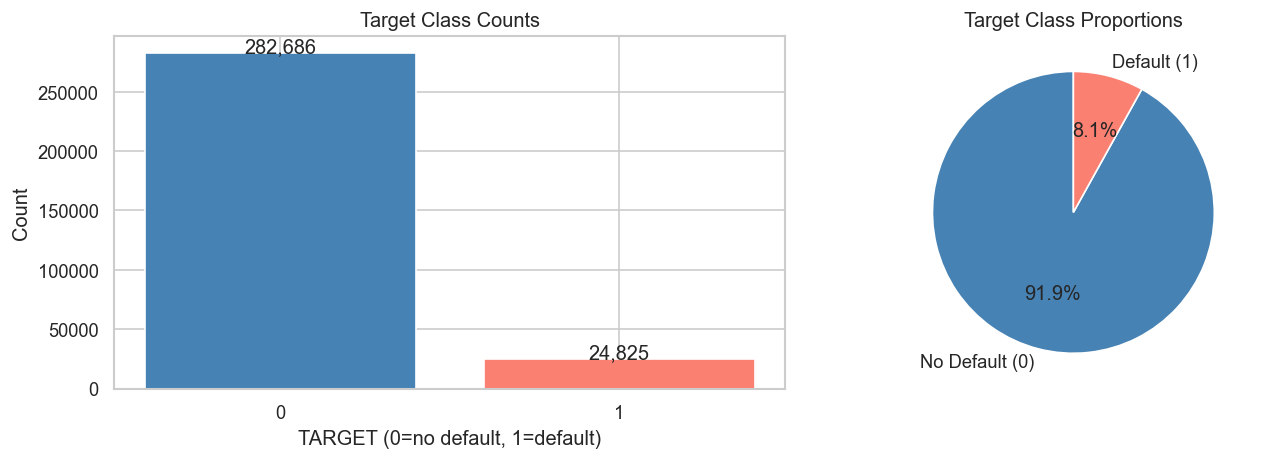

Imbalance ratio: 11.4:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['TARGET'].value_counts()
axes[0].bar(counts.index.astype(str), counts.values, color=['steelblue', 'salmon'])
axes[0].set_title('Target Class Counts')
axes[0].set_xlabel('TARGET (0=no default, 1=default)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center')

axes[1].pie(counts.values, labels=['No Default (0)', 'Default (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Target Class Proportions')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'target_distribution.png', bbox_inches='tight')
plt.show()
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

## 3. Missing value heatmap (top 30 columns)

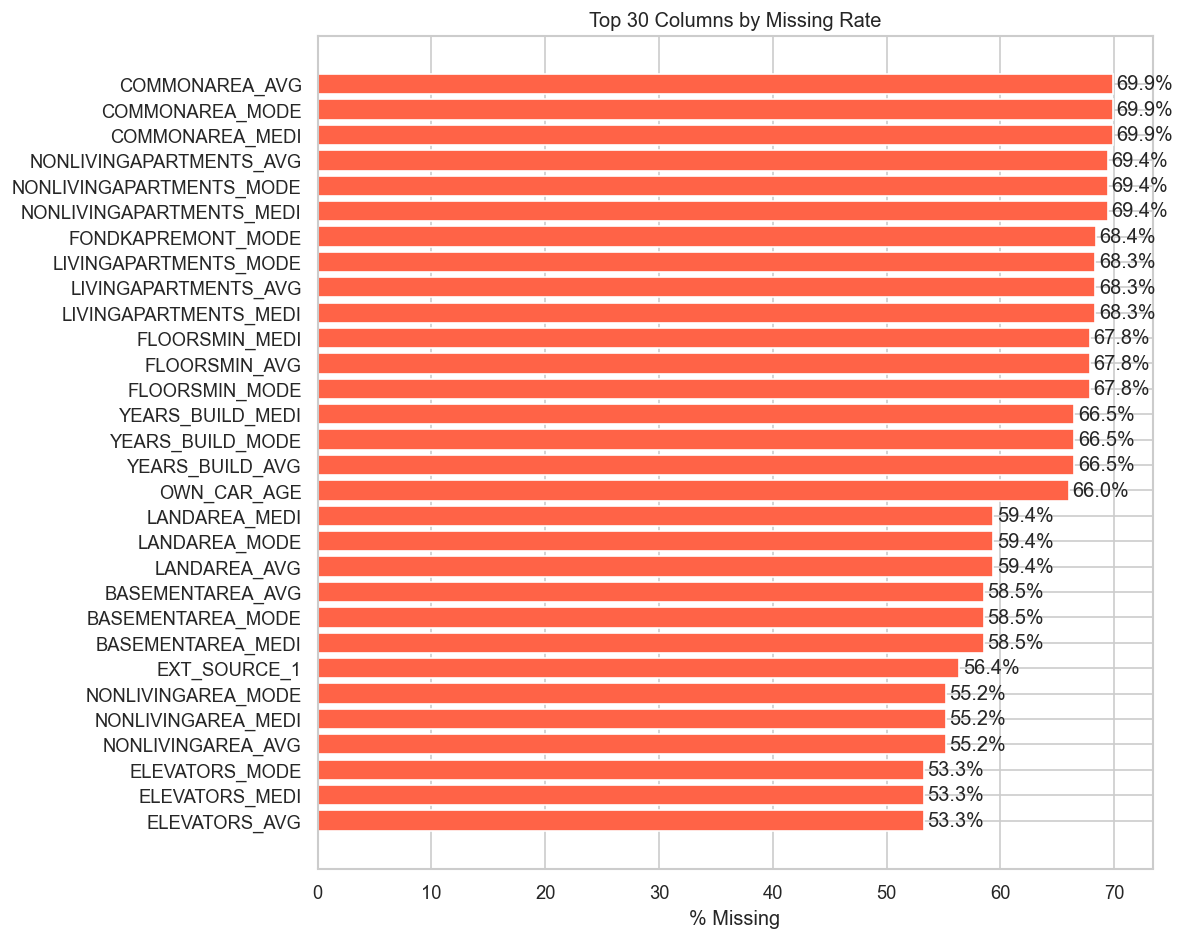

In [5]:
top_missing = summary[summary['pct_null'] > 0].sort_values('pct_null', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_missing.index, top_missing['pct_null'], color='tomato')
ax.set_xlabel('% Missing')
ax.set_title('Top 30 Columns by Missing Rate')
ax.invert_yaxis()
for bar, val in zip(bars, top_missing['pct_null']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'missing_values.png', bbox_inches='tight')
plt.show()

## 4. Numeric feature distributions

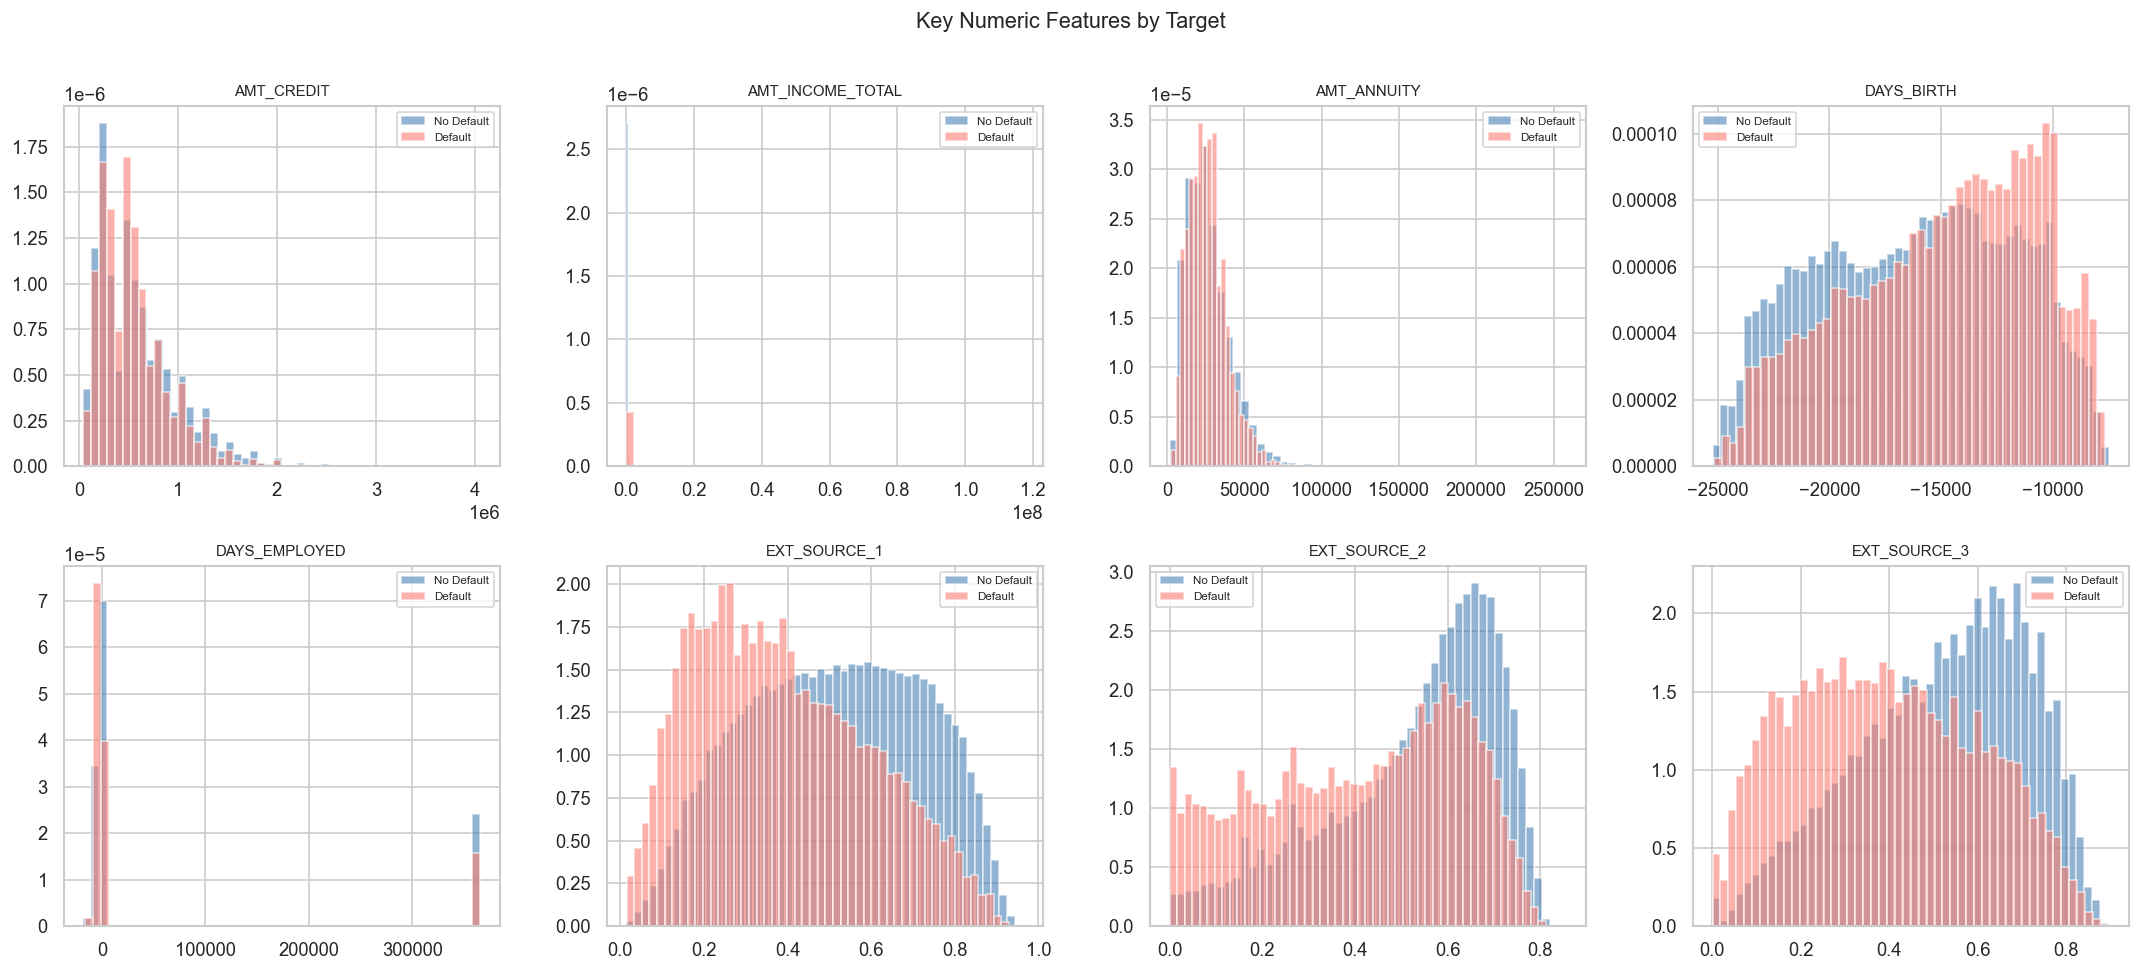

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('TARGET', errors='ignore').tolist()
key_num  = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'DAYS_BIRTH',
             'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
key_num  = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(key_num[:8]):
    data0 = df.loc[df['TARGET'] == 0, col].dropna()
    data1 = df.loc[df['TARGET'] == 1, col].dropna()
    axes[i].hist(data0, bins=50, alpha=0.6, label='No Default', color='steelblue', density=True)
    axes[i].hist(data1, bins=50, alpha=0.6, label='Default',    color='salmon',    density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle('Key Numeric Features by Target', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'numeric_distributions.png', bbox_inches='tight')
plt.show()

## 5. Correlation heatmap (numeric)

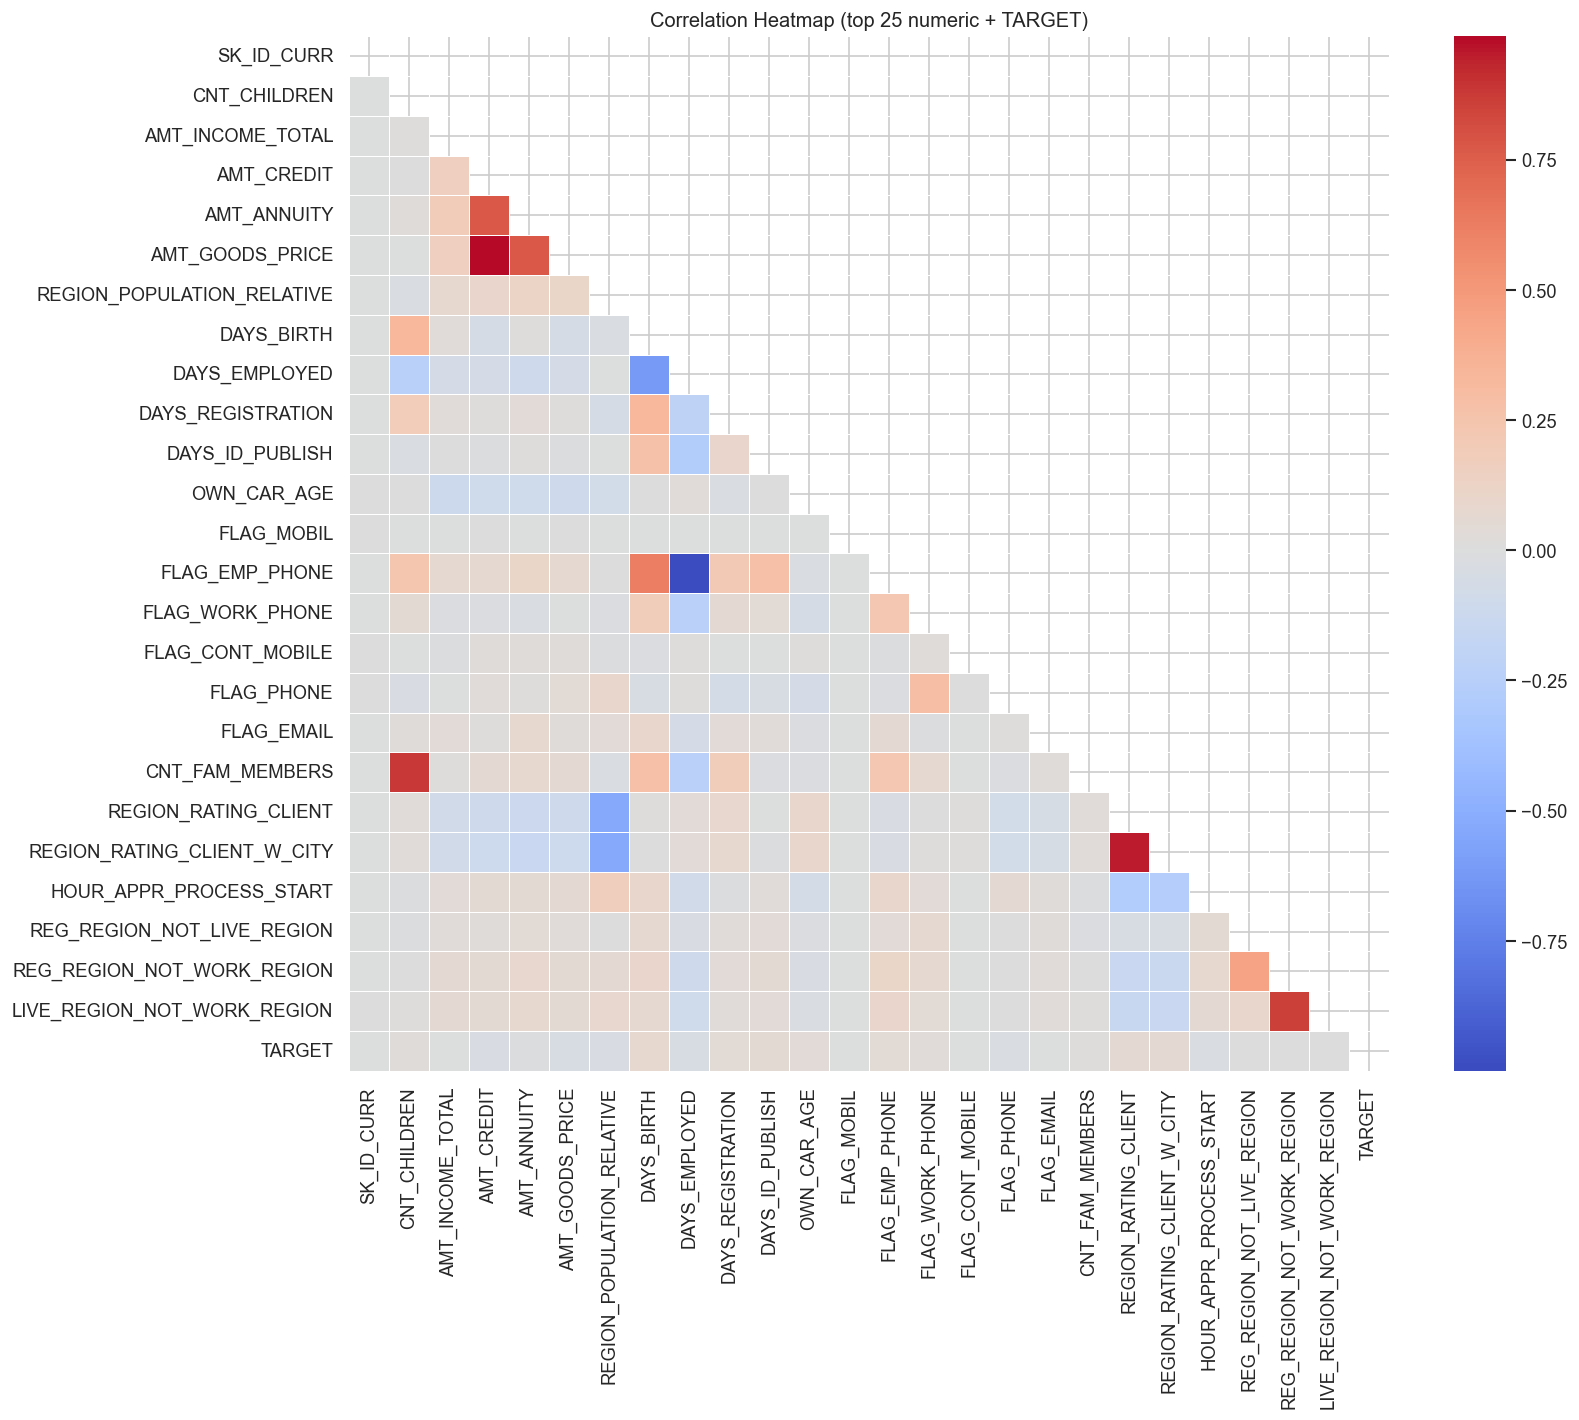

In [7]:
corr_cols = [c for c in num_cols[:25]] + ['TARGET']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Correlation Heatmap (top 25 numeric + TARGET)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Categorical feature analysis

Categorical columns (16): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


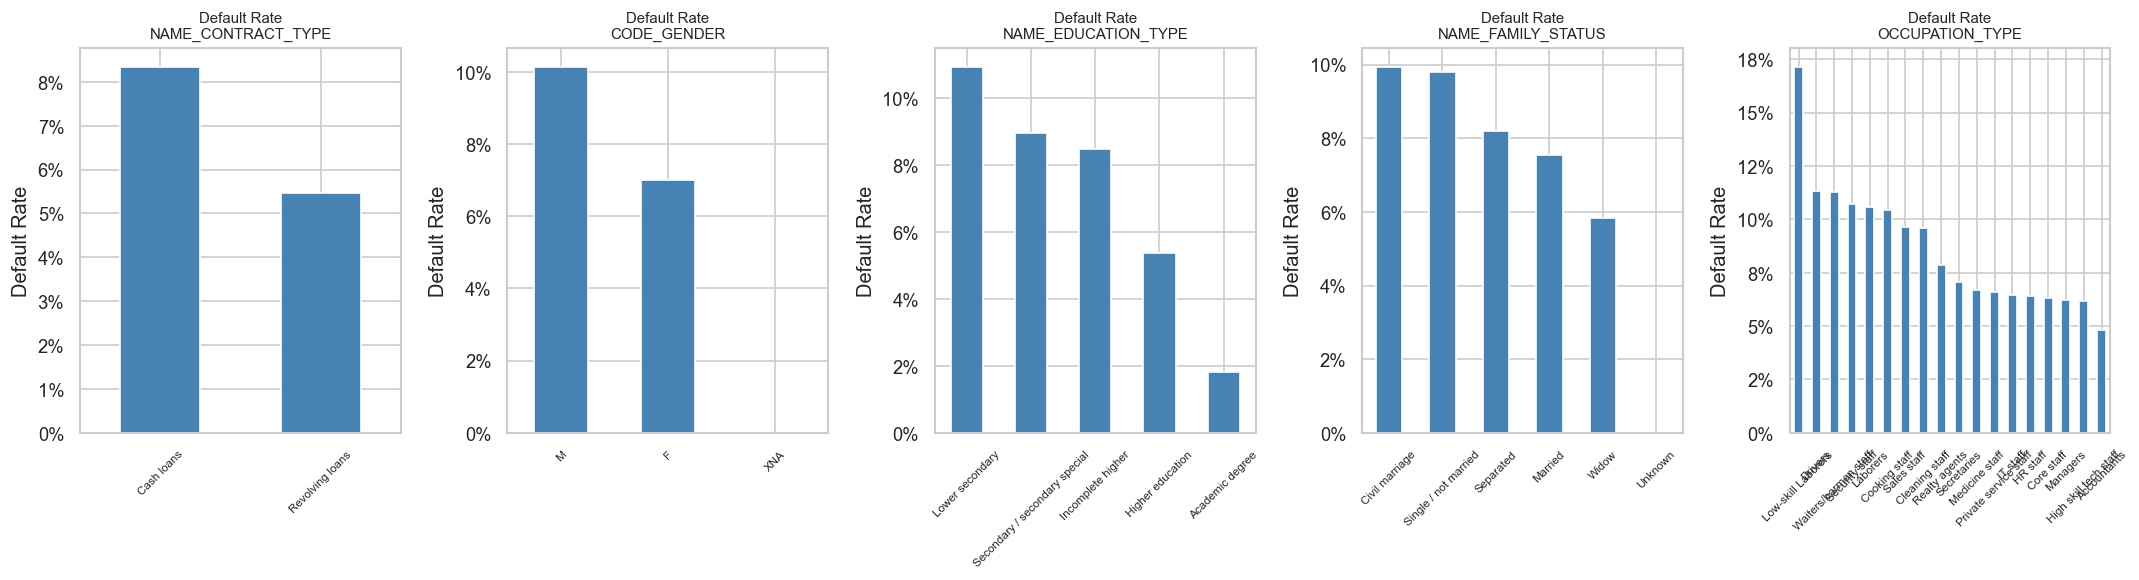

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

key_cats = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
             'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE']
key_cats = [c for c in key_cats if c in df.columns]

fig, axes = plt.subplots(1, len(key_cats), figsize=(18, 5))
for ax, col in zip(axes, key_cats):
    default_rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    default_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Default Rate\n{col}', fontsize=9)
    ax.set_ylabel('Default Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'categorical_default_rates.png', bbox_inches='tight')
plt.show()

## 7. EXT_SOURCE scores vs Target

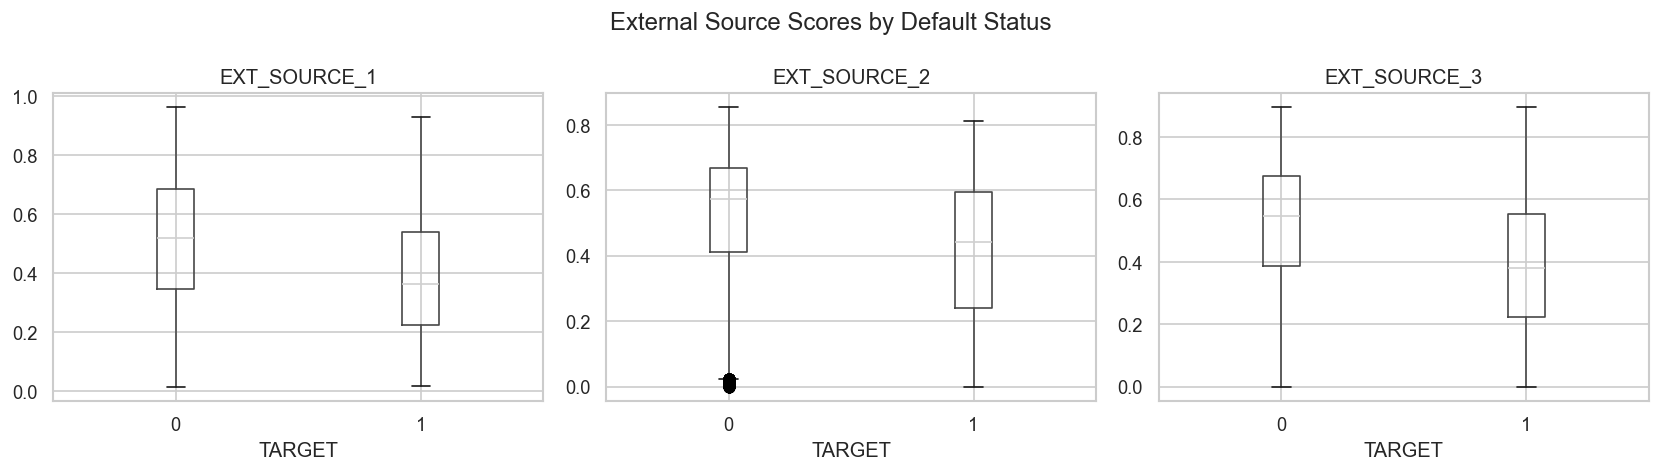

In [9]:
ext_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in df.columns]

fig, axes = plt.subplots(1, len(ext_cols), figsize=(14, 4))
if len(ext_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, ext_cols):
    df.boxplot(column=col, by='TARGET', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('TARGET')
plt.suptitle('External Source Scores by Default Status')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'ext_source_boxplots.png', bbox_inches='tight')
plt.show()

## Summary
All charts saved to `data/processed/eda_charts/`. Proceed to `02_baseline.ipynb`.